**Index No.:** 230280L  
**Name:** J. A. P. R. Jayasinghe  

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Question 1**

In [7]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)

    im_float = im.astype(np.float64)
    out = np.zeros_like(im_float)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, no input range to map

        mask = (im_float >= x0) & (im_float < x1)
        slope = (y1 - y0) / (x1 - x0)
        out[mask] = y0 + slope * (im_float[mask] - x0)

    out[im_float == breakpoints[-1, 0]] = breakpoints[-1, 1]
    out = np.clip(out, 0, 255).astype(np.uint8)

    # Build a 256-point curve for plotting only
    all_x = np.arange(256, dtype=np.float64)
    curve = np.zeros_like(all_x)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        mask = (all_x >= x0) & (all_x < x1)
        slope = (y1 - y0) / (x1 - x0)
        curve[mask] = y0 + slope * (all_x[mask] - x0)
    curve[-1] = breakpoints[-1, 1]

    return out, curve

In [8]:
img = cv2.imread('Images/img1.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [50, 100],
    [100, 175],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed, curve = intensity_transform(img, breakpoints)

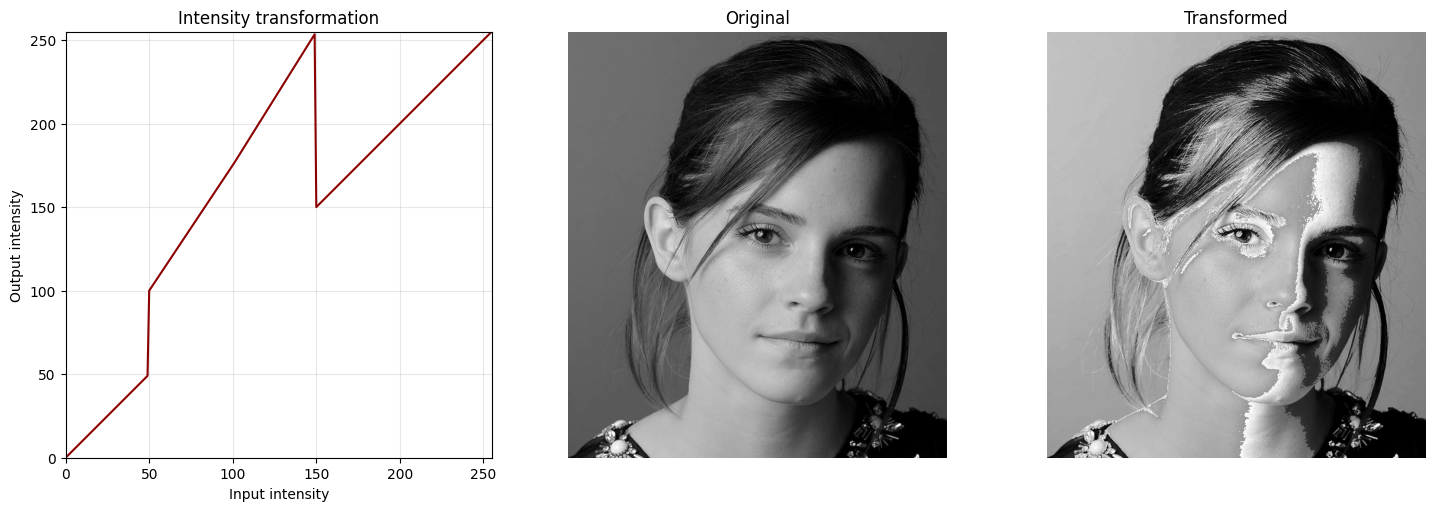

In [9]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), curve, color='darkred')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 2**

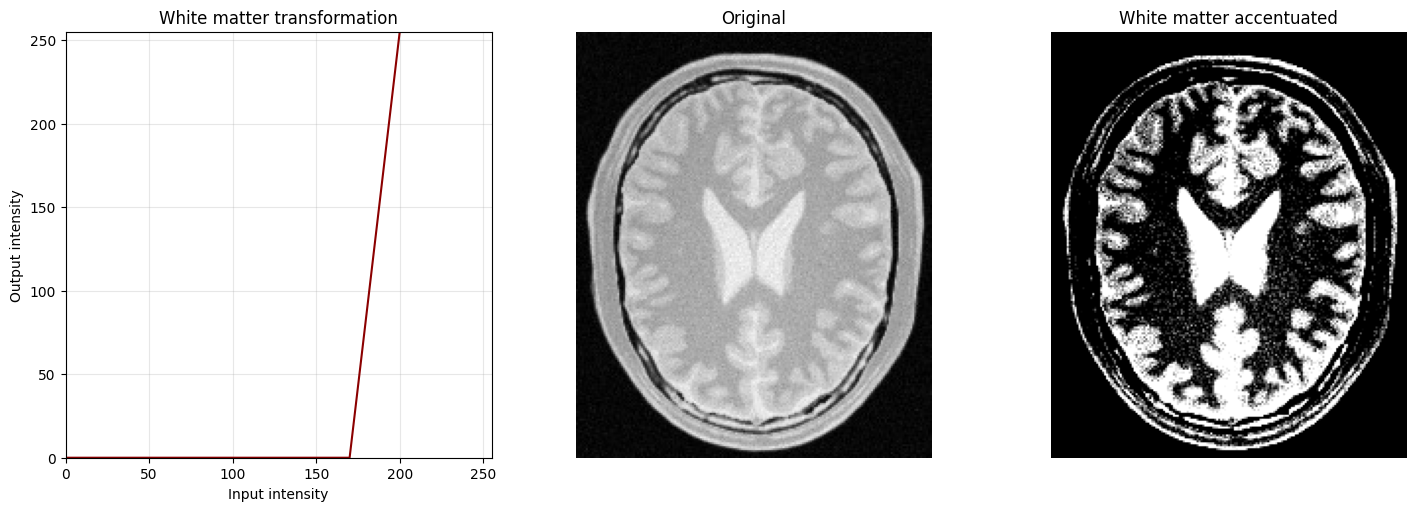

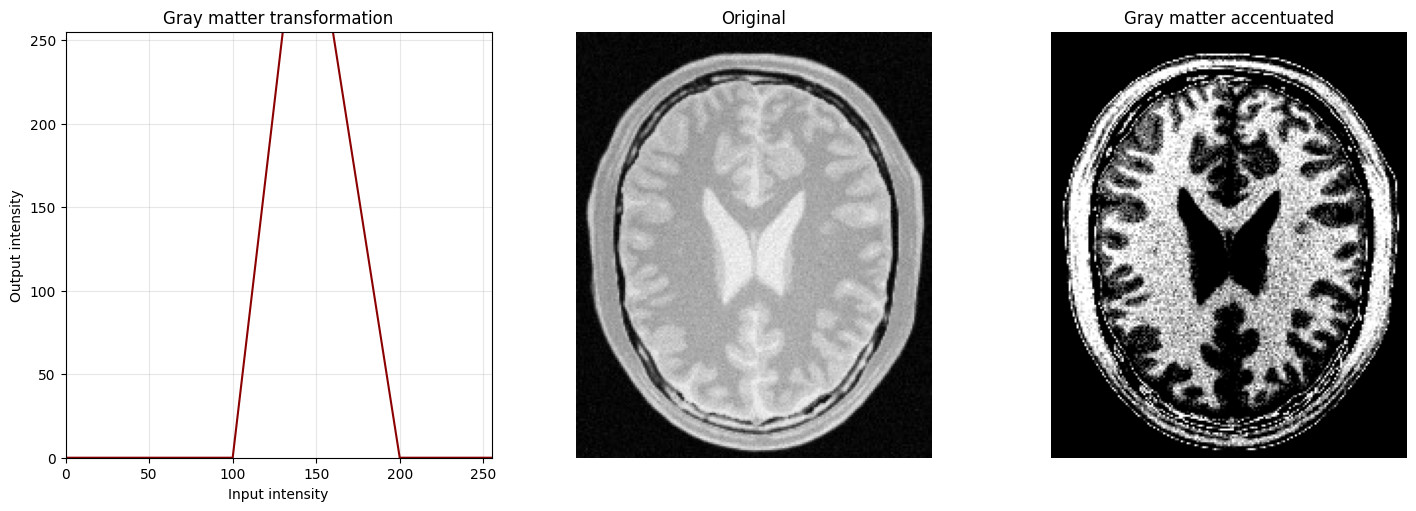

In [10]:
brain = cv2.imread('Images/img2.jpeg', cv2.IMREAD_GRAYSCALE)

# Transform all white matter to maximum intensity.
white_matter_breakpoints = [
    [0, 0],
    [170, 0],
    [200, 255],
    [255, 255],
]

# Tranform all gray matter to maximum intensity
gray_matter_breakpoints = [
    [0, 0],
    [100, 0],
    [130, 255],
    [160, 255],
    [200, 0],
    [255, 0],
]

white_out, white_curve = intensity_transform(brain, white_matter_breakpoints)
gray_out, gray_curve = intensity_transform(brain, gray_matter_breakpoints)

# White matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), white_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('White matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

# Gray matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), gray_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gray matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 3**

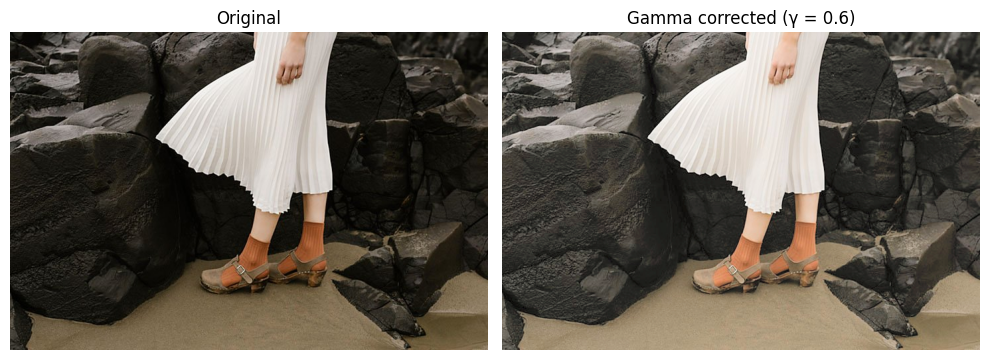

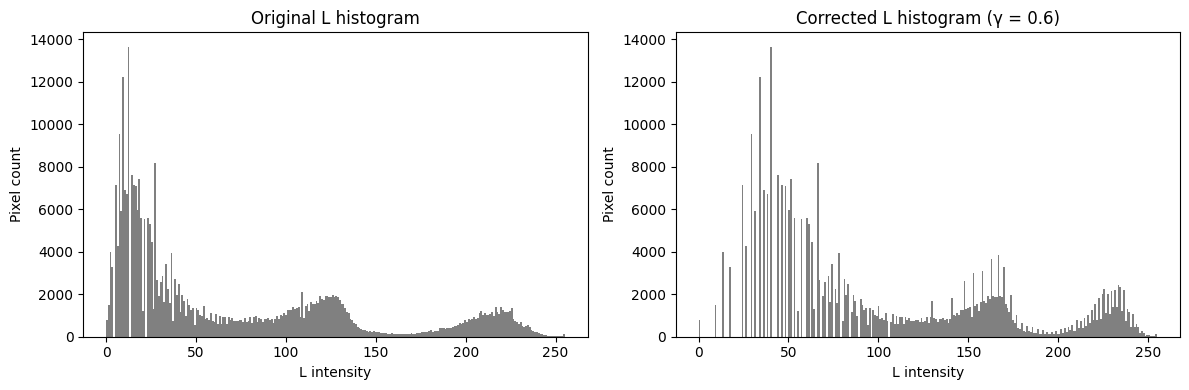

In [12]:
img_bgr = cv2.imread('Images/img3.jpeg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to L*a*b* 
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Apply gamma correction to the L plane
gamma = 0.6

L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])
img_corrected_bgr = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
img_corrected_rgb = cv2.cvtColor(img_corrected_bgr, cv2.COLOR_BGR2RGB)

# Original Image vs Gamma Corrected Image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma corrected (γ = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Histograms of the L plane
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[0].set_xlabel('L intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ = {gamma})')
axes[1].set_xlabel('L intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()